# TP2 - Etapa 2 en Google Colab: dataset, preprocesamiento, entrenamiento y comparacion de modelos

Notebook de trabajo de la Etapa 2: analisis del dataset, preprocesamiento, fine-tuning de
ResNet18 (Modelo A, obligatorio), CNN propia (Modelo B, opcional) y estudio comparativo.

El entrenamiento se realiza en Colab para aprovechar la GPU:
**Entorno de ejecucion -> Cambiar tipo de entorno de ejecucion -> GPU (T4)**.

Requisitos previos (en tu fork):
- `train_classifier`, `evaluate_classifier` y `extract_custom_embedding` implementadas
  en `src/lib/services/classifier_service.py` (esta notebook solo las orquesta).

Al finalizar:
- Descargar los checkpoints generados y colocarlos en `models/` de tu entorno local
  (la aplicacion los usa en las pestañas Etapa 1 y 2 del frontend).
- Publicarlos en un link de solo lectura publico para los docentes.
- Entregar esta notebook ejecutada, con sus salidas.

## Equipo
- Alumno 1 : Almada Manuela
- Alumno 2 : Sanz Alfredo

## 1. Clonar el repositorio

Si tu fork es privado, genera un token de acceso (GitHub -> Settings -> Developer settings ->
Personal access tokens) y usalo en la URL, o sube un zip del proyecto a Colab/Drive.

In [9]:
from getpass import getpass

# Token de GitHub (Settings -> Developer settings -> Personal access tokens).
# Usamos getpass para que el token NO quede guardado en este notebook .
TOKEN = getpass("GitHub token: ")
REPO_URL = f"https://{TOKEN}@github.com/manuela-almada/tuia-dog-recognition-app.git"

!git clone -b _aves $REPO_URL proyecto
%cd proyecto

GitHub token: ··········
Cloning into 'proyecto'...
remote: Enumerating objects: 144, done.
remote: Counting objects: 100% (144/144), done.
remote: Compressing objects: 100% (92/92), done.
remote: Total 144 (delta 71), reused 122 (delta 49), pack-reused 0 (from 0)
Receiving objects: 100% (144/144), 502.10 KiB | 11.68 MiB/s, done.
Resolving deltas: 100% (71/71), done.
/content/proyecto/proyecto


In [10]:
!git branch --show-current
!ls src/lib/services/

_aves
classifier_service.py  __init__.py	      task_manager.py
detection_service.py   similarity_service.py


## 2. Instalar dependencias

Colab ya incluye torch, torchvision, opencv, numpy, scikit-learn y matplotlib;
solo se instala lo que falta.

In [11]:
!pip install -q pydantic-settings python-dotenv kagglehub albumentations onnxruntime

## 3. Configuracion del entorno

En Colab no hay PostgreSQL; la Etapa 2 no usa la base vectorial, por lo que se desactiva
pgvector. La configuracion se define por variables de entorno **antes** de importar `lib`.

In [12]:
import os
import sys
from pathlib import Path

os.environ["USE_PGVECTOR"] = "false"
# Ajusta aca cualquier otra variable (IMAGE_SIZE, EMBEDDING_DIM, paths, etc.)

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from lib.config import settings

import torch
print("dataset_path:", settings.dataset_path)
print("GPU disponible:", torch.cuda.is_available())

dataset_path: data/dataset
GPU disponible: False


In [13]:
# Verificamos dependencias
from lib.bootstrap import build_classifier
print("bootstrap OK")

bootstrap OK


## 4. Descargar el dataset

In [14]:
from google.colab import files
print("Subí tu kaggle.json (lo tenés en ~/.kaggle/ de tu máquina):")
files.upload()
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
print("Kaggle configurado ✅")

Subí tu kaggle.json (lo tenés en ~/.kaggle/ de tu máquina):


Saving kaggle.json to kaggle.json
Kaggle configurado ✅


In [15]:
!python scripts/download_dataset.py
!ls data/dataset

Descargando gpiosenka/70-dog-breedsimage-data-set ...
Using Colab cache for faster access to the '70-dog-breedsimage-data-set' dataset.
Dataset disponible en /content/proyecto/proyecto/data/dataset
dogs.csv  test	train  valid


## 5. Analisis del dataset

TO-DO:
- Analizar la distribucion de clases y documentar la cantidad de imagenes por raza.
- Definir los conjuntos de entrenamiento, validacion y prueba.
- Construir un conjunto independiente para evaluacion (ej: imagenes descargadas de internet).
- Filtrar imagenes de baja calidad (documentar el criterio).

In [ ]:
## TO-DO: analisis exploratorio del dataset (distribucion de clases, imagenes por raza, splits).

## 6. Preprocesamiento

TO-DO: definir y justificar resize, normalizacion y data augmentation (horizontal flip,
rotacion, blur, variaciones de brillo y contraste, ruido).

In [ ]:
## TO-DO: transformaciones de preprocesamiento y data augmentation (con ejemplos visuales).

## 7. Modelo A (obligatorio): fine-tuning de ResNet18

`train_classifier` debe guardar el checkpoint en `models/resnet18_finetuned.pth`
(o el nombre configurado en RESNET18_MODEL_NAME). Documentar los hiperparametros
utilizados (learning rate, batch size, epochs, optimizador, scheduler).

Tiempo de Ejecución estimado para esta celda: 8 minuntos (Entorno GPU)

In [ ]:
from lib.bootstrap import build_classifier

classifier = build_classifier(settings)
classifier.set_active_model("resnet18_finetuned")
classifier.train_classifier()

In [ ]:
!ls -lh models/

total 43M
-rw-r--r-- 1 root root 43M Jun 19 15:50 resnet18_finetuned.pth


In [ ]:
metrics_a = classifier.evaluate_classifier()
metrics_a

{'accuracy': 0.9642857142857143,
 'precision': 0.9678231292517006,
 'recall': 0.9642857142857143,
 'specificity': 0.9994824016563147,
 'f1': 0.9637965584958065}

### Curvas de entrenamiento y matriz de confusion (Modelo A)


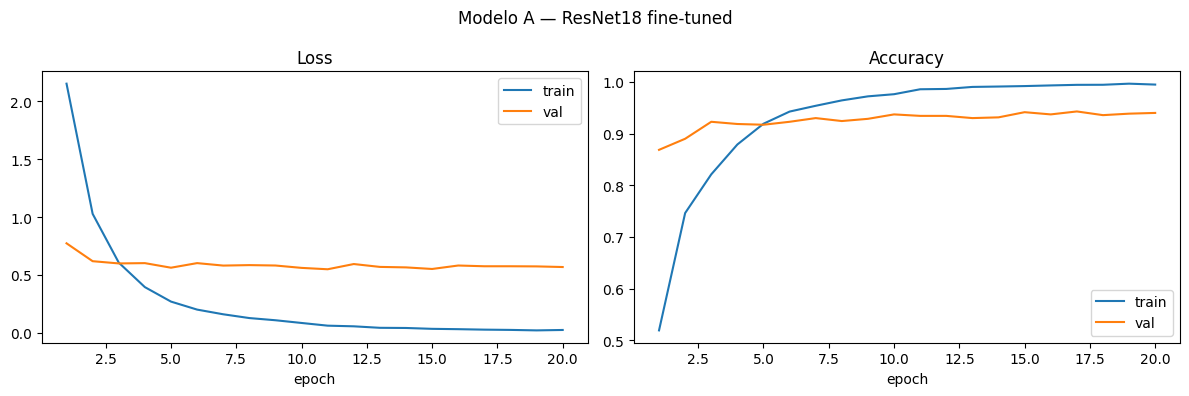

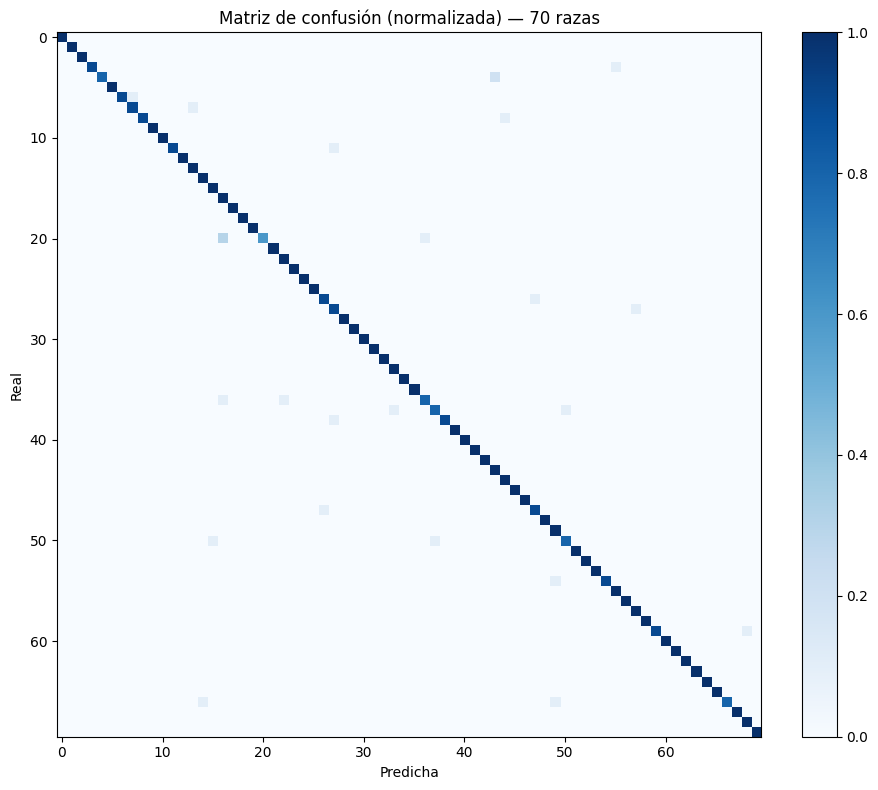

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

h = classifier.history
ev = classifier.last_eval

# --- Curvas de entrenamiento ---
epochs = range(1, len(h["train_loss"]) + 1)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(epochs, h["train_loss"], label="train"); ax[0].plot(epochs, h["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(epochs, h["train_acc"], label="train"); ax[1].plot(epochs, h["val_acc"], label="val")
ax[1].set_title("Accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.suptitle("Modelo A — ResNet18 fine-tuned"); plt.tight_layout(); plt.show()

# --- Matriz de confusion (normalizada por clase real) ---
cm = ev["cm"].astype(float)
cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
ax.set_title(f"Matriz de confusión (normalizada) — {len(ev['classes'])} razas")
ax.set_xlabel("Predicha"); ax.set_ylabel("Real")
fig.colorbar(im, ax=ax, fraction=0.046); plt.tight_layout(); plt.show()

## 8. Modelo B (opcional, recomendado): CNN propia

`train_classifier` con el modelo activo `cnn_custom` debe guardar el checkpoint en
`models/cnn_custom.pth` (o el nombre configurado en CNN_CUSTOM_MODEL_NAME).

La CNN propia tiene cinco bloques.

Cada bloque hace dos cosas: primero mira la imagen con filtros (convolución: detecta patrones), después la achica a la mitad (pooling: se queda con lo importante).

A medida que avanzamos, la imagen se hace más chica pero la describimos con más canales (más tipos de patrones detectados a la vez):

*   Bloque 1: 224→112 píxeles, 3→32 canales — detecta bordes y colores simples.
*   Bloque 2: 112→56 píxeles, 32→64 canales — texturas (pelo, manchas).
*   Bloque 3: 56→28 píxeles, 64→128 canales — partes (orejas, hocico).
*   Bloque 4: 28→14 píxeles, 128→256 canales — combinaciones de partes.
*   Bloque 5: 14→7 píxeles, 256→512 canales — formas más completas, propias de cada raza.


In [ ]:
classifier.set_active_model("cnn_custom")
classifier.train_classifier()
metrics_b = classifier.evaluate_classifier()
metrics_b

{'accuracy': 0.6942857142857143,
 'precision': 0.715621197933228,
 'recall': 0.6942857142857143,
 'specificity': 0.9955693581780539,
 'f1': 0.6841975536926066}

In [ ]:
!grep -n "CustomCNNClassifier" /content/proyecto/src/lib/services/classifier_service.py

52:class CustomCNNClassifier(nn.Module):
371:            return CustomCNNClassifier(num_classes=num_classes)


In [ ]:
eval_b = classifier.last_eval   # matriz de confusión del Modelo B (CNN), antes de que se pise

In [ ]:
classifier.set_active_model("resnet18_finetuned")
metrics_a = classifier.evaluate_classifier()   # carga la ResNet ya entrenada y la evalúa (sin reentrenar)
eval_a = classifier.last_eval                  # matriz de confusión del Modelo A (ResNet)
metrics_a

{'accuracy': 0.9642857142857143,
 'precision': 0.9678231292517006,
 'recall': 0.9642857142857143,
 'specificity': 0.9994824016563147,
 'f1': 0.9637965584958065}

In [ ]:
history_b = classifier.history   # curvas de la CNN (Modelo B), antes de que se pisen

## 9. Estudio comparativo

TO-DO (pequeño estudio de la Etapa 2):
- Comparar los modelos entrenados: accuracy, precision, recall, specificity, F1.
- Analizar las clases con peor desempeño (falsos positivos / falsos negativos).
- Discutir trade-offs (performance vs costo computacional).
- Copiar las conclusiones al informe (`informe.ipynb`).

In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "ResNet18 (fine-tuned)": metrics_a,
    "CNN propia": metrics_b,
})
comparison["diferencia (A - B)"] = comparison["ResNet18 (fine-tuned)"] - comparison["CNN propia"]
comparison.index.name = "métrica"
comparison.round(4)

,ResNet18 (fine-tuned),CNN propia,diferencia (A - B)
métrica,,,
accuracy,0.9643,0.6943,0.2700
precision,0.9678,0.7156,0.2522
recall,0.9643,0.6943,0.2700
specificity,0.9995,0.9956,0.0039
f1,0.9638,0.6842,0.2796


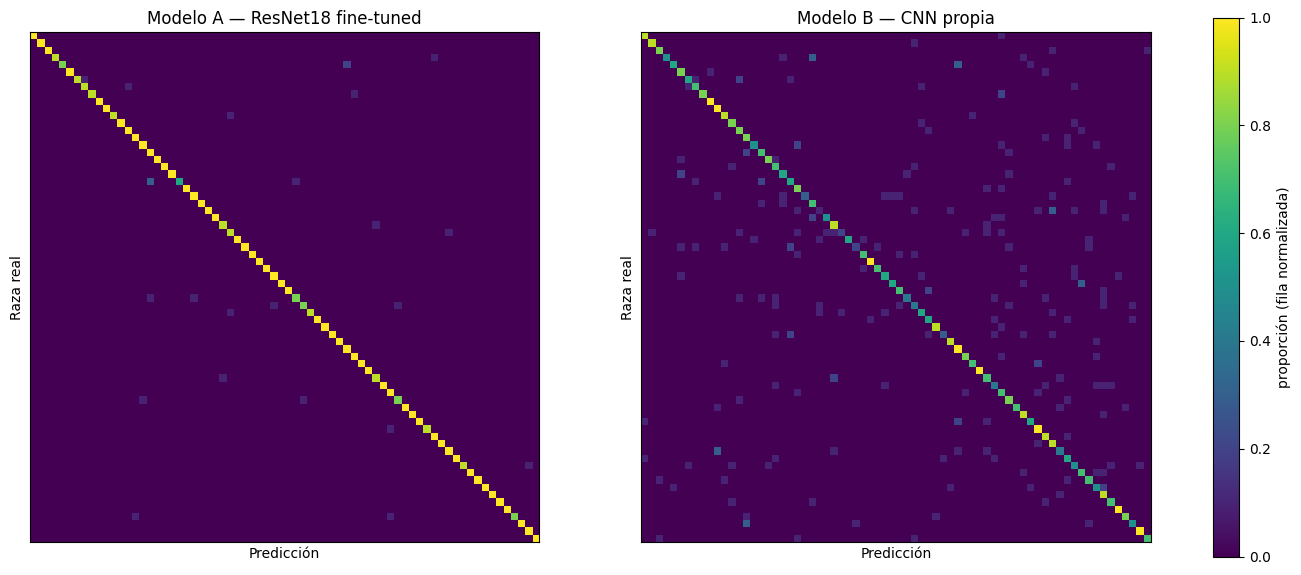

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_confusion(eval_data, title, ax):
    cm = eval_data["cm"].astype(float)
    # Normalizamos por fila (cada fila es una raza real) -> proporciones 0..1, color comparable
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm), where=row_sums != 0)
    im = ax.imshow(cm_norm, cmap="viridis", vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Raza real")
    ax.set_xticks([]); ax.set_yticks([])   # 70 etiquetas no entran legibles
    return im

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plot_confusion(eval_a, "Modelo A — ResNet18 fine-tuned", axes[0])
im = plot_confusion(eval_b, "Modelo B — CNN propia", axes[1])
fig.colorbar(im, ax=axes, fraction=0.046, label="proporción (fila normalizada)")
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from IPython.display import display

def top_confusions(eval_data, n=10):
    """Pares (raza real -> predicho) que más se confunden, ignorando la diagonal (aciertos)."""
    cm = eval_data["cm"].copy()
    classes = eval_data["classes"]
    np.fill_diagonal(cm, 0)                      # sacamos los aciertos, solo miramos confusiones
    order = np.argsort(cm, axis=None)[::-1]      # celdas de mayor a menor
    rows = []
    for idx in order[:n]:
        i, j = np.unravel_index(idx, cm.shape)
        if cm[i, j] == 0:
            break
        rows.append({"raza real": classes[i], "predicho como": classes[j], "veces": int(cm[i, j])})
    return pd.DataFrame(rows)

print("Modelo B — CNN propia: pares más confundidos")
display(top_confusions(eval_b, n=10))
print("\nModelo A — ResNet18 fine-tuned: pares más confundidos")
display(top_confusions(eval_a, n=10))

## 10. Descargar los checkpoints

Descargalos y colocalos en `models/` de tu entorno local para que la aplicacion los use
(pestañas Etapa 1 y 2 del frontend). Recorda publicarlos en un link de solo lectura publico.

In [ ]:
!ls -lh models/

try:
    from google.colab import files

    files.download(str(settings.model_path / settings.resnet18_model_name))
    # files.download(str(settings.model_path / settings.cnn_custom_model_name))
except ImportError:
    print("Fuera de Colab: los checkpoints quedan en models/")

total 43M
-rw-r--r-- 1 root root 43M Jun 19 01:06 resnet18_finetuned.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>